# TP Integrador: Optimización y Despliegue de IA en Entornos Restringidos

## Problema: Clasificación de imágenes del Alfabeto de Lenguaje de Señas (ASL)
**Dataset:** ASL Alphabet (Kaggle - grassknoted/asl-alphabet)

---

### Fase 1 — Definición del problema y restricciones

| Aspecto | Detalle |
|---|---|
| **Caso de uso** | Clasificación de imágenes de señas del alfabeto ASL (29 clases: A-Z + del, nothing, space) |
| **Plataforma de despliegue** | PC estándar con restricción de uso exclusivo de **CPU** |
| **Accuracy drop máximo** | ≤ 2% respecto al modelo baseline |
| **Tamaño máximo del modelo** | ≤ 10 MB en disco |
| **Latencia máxima** | ≤ 50 ms por inferencia en CPU |

In [1]:
!pip install kagglehub

#### Funciones auxiliares

In [2]:
def print_comparison_table(models_dict, metrics=None):
    """
    models_dict: dict
        {
            "FP32 CPU": {...},
            "FP32 GPU": {...},
            "INT8 Dynamic": {...},
            "INT8 Static": {...},
        }

    metrics: list de tuplas (label, key)
        Ej: [("Accuracy (%)", "test_acc"), ...]
    """

    if metrics is None:
        metrics = [
            ("Accuracy (%)",       "test_acc"),
            ("Tamaño (MB)",        "size"),
            ("Latencia device (ms)", "latency"),
            ("FPS device",         "fps"),
            ("Latencia CPU (ms)",  "latency_cpu"),
            ("FPS CPU",            "fps_cpu"),
        ]

    model_names = list(models_dict.keys())

    # ancho dinámico
    col_width = 15
    total_width = 25 + col_width * len(model_names)

    print("\n" + "=" * total_width)
    print("COMPARACIÓN FINAL")
    print("=" * total_width)

    # header
    header = f"{'Métrica':<25}"
    for name in model_names:
        header += f"{name:>{col_width}}"
    print(header)

    print("-" * total_width)

    def safe_get(d, key):
        if d is None:
            return "-"
        val = d.get(key, "-")
        return f"{val:.3f}" if isinstance(val, (int, float)) else val

    # filas
    for metric_name, key in metrics:
        row = f"{metric_name:<25}"
        for model in model_names:
            row += f"{safe_get(models_dict[model], key):>{col_width}}"
        print(row)

    print("=" * total_width)

In [3]:
def evaluate_model(model, name, device):
    model = model.to(device)
    model.eval()

    print("\n" + "=" * 60)
    print(f"MÉTRICAS - {name} ({device})")
    print("=" * 60)

    # ============================================================
    # 1. Accuracy y Loss
    # ============================================================
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    test_loss, test_acc = validate(model, test_loader, criterion, device)

    # ============================================================
    # 2. Tamaño en disco
    # ============================================================
    path = f"{name}.pth"
    torch.save(model.state_dict(), path)
    size_mb = os.path.getsize(path) / (1024 ** 2)

    # ============================================================
    # 3. Latencia en device actual
    # ============================================================
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

    # Warm-up
    for _ in range(25):
        model(dummy)

    latencies = []
    for _ in range(100):
        if device.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        with torch.no_grad():
            model(dummy)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        latencies.append((t1 - t0) * 1000)

    avg_latency = np.mean(latencies)
    std_latency = np.std(latencies)
    fps = 1000.0 / avg_latency

    # ============================================================
    # 4. Latencia en CPU (siempre medimos)
    # ============================================================
    if device.type == "cuda":
        import copy
        model_cpu = copy.deepcopy(model).to("cpu")
        model_cpu.eval()
        dummy_cpu = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

        for _ in range(25):
            model_cpu(dummy_cpu)

        latencies_cpu = []
        for _ in range(100):
            t0 = time.perf_counter()
            with torch.no_grad():
                model_cpu(dummy_cpu)
            t1 = time.perf_counter()
            latencies_cpu.append((t1 - t0) * 1000)

        avg_latency_cpu = np.mean(latencies_cpu)
        fps_cpu = 1000.0 / avg_latency_cpu
    else:
        # Ya estamos en CPU — reutilizamos las mismas métricas
        avg_latency_cpu = avg_latency
        fps_cpu = fps

    # ============================================================
    # 5. Peak Memory GPU
    # ============================================================
    peak_mem = None
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            _ = model(dummy)
        peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)

    # ============================================================
    # PRINT ESTILO TABLA (como baseline)
    # ============================================================
    print(f"{'Métrica':<35} {'Valor':>20}")
    print("-" * 60)
    print(f"{'Accuracy (validación)':<35} {val_acc:>19.2f}%")
    print(f"{'Loss (validación)':<35} {val_loss:>20.4f}")
    print(f"{'Accuracy (test)':<35} {test_acc:>19.2f}%")
    print(f"{'Loss (test)':<35} {test_loss:>20.4f}")
    print(f"{'Tamaño en disco':<35} {size_mb:>18.2f} MB")
    print(f"{'Latencia (' + device.type + ')':<35} {avg_latency:>18.2f} ms")
    print(f"{'FPS (' + device.type + ')':<35} {fps:>20.1f}")
    print(f"{'Latencia CPU (ms)':<35} {avg_latency_cpu:>18.2f} ms")
    print(f"{'FPS CPU':<35} {fps_cpu:>20.1f}")

    if peak_mem is not None:
        print(f"{'Peak Memory GPU':<35} {peak_mem:>18.2f} MB")

    print("=" * 60)

    # ============================================================
    # RETURN (lo mantenemos como pediste)
    # ============================================================
    return {
        "test_acc": test_acc,
        "size": size_mb,
        "latency": avg_latency,
        "fps": fps,
        "latency_cpu": avg_latency_cpu,
        "fps_cpu": fps_cpu
    }

In [4]:
# --- Imports ---
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import kagglehub
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import random

Mounted at /content/drive


### Import de dataset

In [5]:
# -----------------------------
# Descargar dataset
# -----------------------------
path = kagglehub.dataset_download("nishchalchandel/raf-db-face-emotion-dataset")
print("Path:", path)
'''
src_dir = os.path.join(path, "asl_alphabet_train", "asl_alphabet_train")

# -----------------------------
# CONFIG
# -----------------------------
dst_base = "/content/drive/MyDrive/CEIA/IAE/TP/asl_small"

split_total = 0.3
train_ratio = 0.6
val_ratio   = 0.2
test_ratio  = 0.2

random.seed(42)

# -----------------------------
# Validación: si ya existe, saltar
# -----------------------------
splits = ["train", "val", "test"]

already_exists = all(
    os.path.isdir(os.path.join(dst_base, split)) and
    len(os.listdir(os.path.join(dst_base, split))) > 0
    for split in splits
)

if already_exists:
    print("✅ El dataset ya existe en Drive, se omite la creación.")
else:
    # Crear estructura destino
    for split in splits:
        os.makedirs(os.path.join(dst_base, split), exist_ok=True)

    # -----------------------------
    # Procesar por clase
    # -----------------------------
    classes = os.listdir(src_dir)

    for cls in classes:
        src_class_path = os.path.join(src_dir, cls)

        if not os.path.isdir(src_class_path):
            continue

        images = sorted(os.listdir(src_class_path))

        # -----------------------------
        # 1. Tomar 30% total
        # -----------------------------
        n_total = int(len(images) * split_total)
        selected = images[:n_total]

        # -----------------------------
        # 2. Split 60/20/20
        # -----------------------------
        n_train = int(n_total * train_ratio)
        n_val   = int(n_total * val_ratio)

        train_imgs = selected[:n_train]
        val_imgs   = selected[n_train:n_train + n_val]
        test_imgs  = selected[n_train + n_val:]

        print(f"{cls}: total={len(images)} → usando={n_total} "
              f"(train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)})")

        # -----------------------------
        # 3. Copiar archivos
        # -----------------------------
        for split_name, split_imgs in zip(splits, [train_imgs, val_imgs, test_imgs]):
            dst_class_path = os.path.join(dst_base, split_name, cls)
            os.makedirs(dst_class_path, exist_ok=True)

            for img in split_imgs:
                shutil.copy2(
                    os.path.join(src_class_path, img),
                    os.path.join(dst_class_path, img)
                )

    print("\n✅ Dataset reducido y dividido correctamente")
    '''

100%|██████████| 37.6M/37.6M [00:00<00:00, 84.7MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/nishchalchandel/raf-db-face-emotion-dataset/versions/3


'\nsrc_dir = os.path.join(path, "asl_alphabet_train", "asl_alphabet_train")\n\n# -----------------------------\n# CONFIG\n# -----------------------------\ndst_base = "/content/drive/MyDrive/CEIA/IAE/TP/asl_small"\n\nsplit_total = 0.3\ntrain_ratio = 0.6\nval_ratio   = 0.2\ntest_ratio  = 0.2\n\nrandom.seed(42)\n\n# -----------------------------\n# Validación: si ya existe, saltar\n# -----------------------------\nsplits = ["train", "val", "test"]\n\nalready_exists = all(\n    os.path.isdir(os.path.join(dst_base, split)) and\n    len(os.listdir(os.path.join(dst_base, split))) > 0\n    for split in splits\n)\n\nif already_exists:\n    print("✅ El dataset ya existe en Drive, se omite la creación.")\nelse:\n    # Crear estructura destino\n    for split in splits:\n        os.makedirs(os.path.join(dst_base, split), exist_ok=True)\n\n    # -----------------------------\n    # Procesar por clase\n    # -----------------------------\n    classes = os.listdir(src_dir)\n\n    for cls in classes:\n

In [6]:
# ============================================================
# FASE 2 — Arquitectura y Entrenamiento Inicial (Baseline)
# ============================================================

# Para contar parámetros y MACs (complejidad teórica)
# Si no está instalado, ejecutar: !pip install thop
try:
    from thop import profile, clever_format
except ImportError:
    print("Instalando thop para medir MACs...")
    import subprocess
    subprocess.check_call(["pip", "install", "thop"])
    from thop import profile, clever_format

# --- Configuración general ---
# Semilla para reproducibilidad
SEED = 22
torch.manual_seed(SEED)
np.random.seed(SEED)

# Hiperparámetros del entrenamiento
BATCH_SIZE = 64          # Tamaño de batch (ajustar si hay problemas de memoria)
NUM_EPOCHS = 25          # Épocas de entrenamiento
LEARNING_RATE = 1e-3     # Tasa de aprendizaje
IMG_SIZE = 64            # (original: 200x200)
NUM_CLASSES = 7         # face emotions

# Selección automática de dispositivo: usar GPU T4 si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo seleccionado: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Instalando thop para medir MACs...
Dispositivo seleccionado: cuda
GPU: Tesla T4


In [7]:
import shutil
import os

src = '/content/drive/MyDrive/CEIA/IAE/TP/asl_small'
dst = '/content/asl_small'

if not os.path.exists(dst):
    print("Copiando dataset a disco local...")
    shutil.copytree(src, dst)
    print("Copia completa")
else:
    print("Dataset ya copiado")

Copiando dataset a disco local...
Copia completa


In [8]:
# --- Exploración del dataset ---
# El dataset ASL Alphabet tiene carpetas: asl_alphabet_train y asl_alphabet_test
# Cada subcarpeta dentro de train corresponde a una clase (A, B, ..., Z, del, nothing, space)

# Detectar la estructura de carpetas descargada
print(f"Ruta base del dataset: {path}")
print(f"Contenido: {os.listdir(path)}")

# Definir rutas de train y test
train_dir = os.path.join(path, "train")
val_dir = os.path.join(path, "validation")
test_dir = os.path.join(path, "test")

# Verificar que existen; si la estructura es diferente, ajustar
if not os.path.exists(train_dir):
    # Estructura alternativa (sin subcarpeta duplicada)
    train_dir = os.path.join(path, "asl_alphabet_train")
    val_dir = os.path.join(path, "asl_alphabet_val")
    test_dir = os.path.join(path, "asl_alphabet_test")

print(f"\nRuta de entrenamiento: {train_dir}")
print(f"Ruta de val: {val_dir}")
print(f"Ruta de test: {test_dir}")

# Listar las clases encontradas
clases = sorted(os.listdir(train_dir))
print(f"\nClases encontradas ({len(clases)}): {clases}")

# Contar imágenes por clase
total_imgs = 0
for clase in clases:
    n = len(os.listdir(os.path.join(train_dir, clase)))
    total_imgs += n
print(f"\nTotal de imágenes de entrenamiento: {total_imgs}")
print(f"Imágenes por clase (aprox): {total_imgs // len(clases)}")

Ruta base del dataset: /root/.cache/kagglehub/datasets/nishchalchandel/raf-db-face-emotion-dataset/versions/3
Contenido: ['validation', 'train', 'test']

Ruta de entrenamiento: /root/.cache/kagglehub/datasets/nishchalchandel/raf-db-face-emotion-dataset/versions/3/train
Ruta de val: /root/.cache/kagglehub/datasets/nishchalchandel/raf-db-face-emotion-dataset/versions/3/validation
Ruta de test: /root/.cache/kagglehub/datasets/nishchalchandel/raf-db-face-emotion-dataset/versions/3/test

Clases encontradas (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Total de imágenes de entrenamiento: 12271
Imágenes por clase (aprox): 1753


In [9]:
import shutil
import os

def remove_checkpoints(root_dir):
    for root, dirs, files in os.walk(root_dir):
        for d in dirs:
            if d == ".ipynb_checkpoints":
                path = os.path.join(root, d)
                shutil.rmtree(path)
                print(f"Eliminado: {path}")

# Ejecutar en tu dataset
remove_checkpoints("/content/drive/MyDrive/CEIA/IAE/TP/asl_small")

In [10]:

# --- Transformaciones ---
base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- Datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=base_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=base_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=base_transforms)


# --- DataLoaders ---
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# --- Debug ---
imgs, labels = next(iter(train_loader))
print(f"Shape imágenes: {imgs.shape}")
print(f"Shape labels: {labels.shape}")
print(f"Clases: {train_dataset.class_to_idx}")
print(f"Tamaño total original: {len(train_dataset)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Shape imágenes: torch.Size([64, 3, 64, 64])
Shape labels: torch.Size([64])
Clases: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Tamaño total original: 12271
Train: 12271 | Val: 1533 | Test: 1535


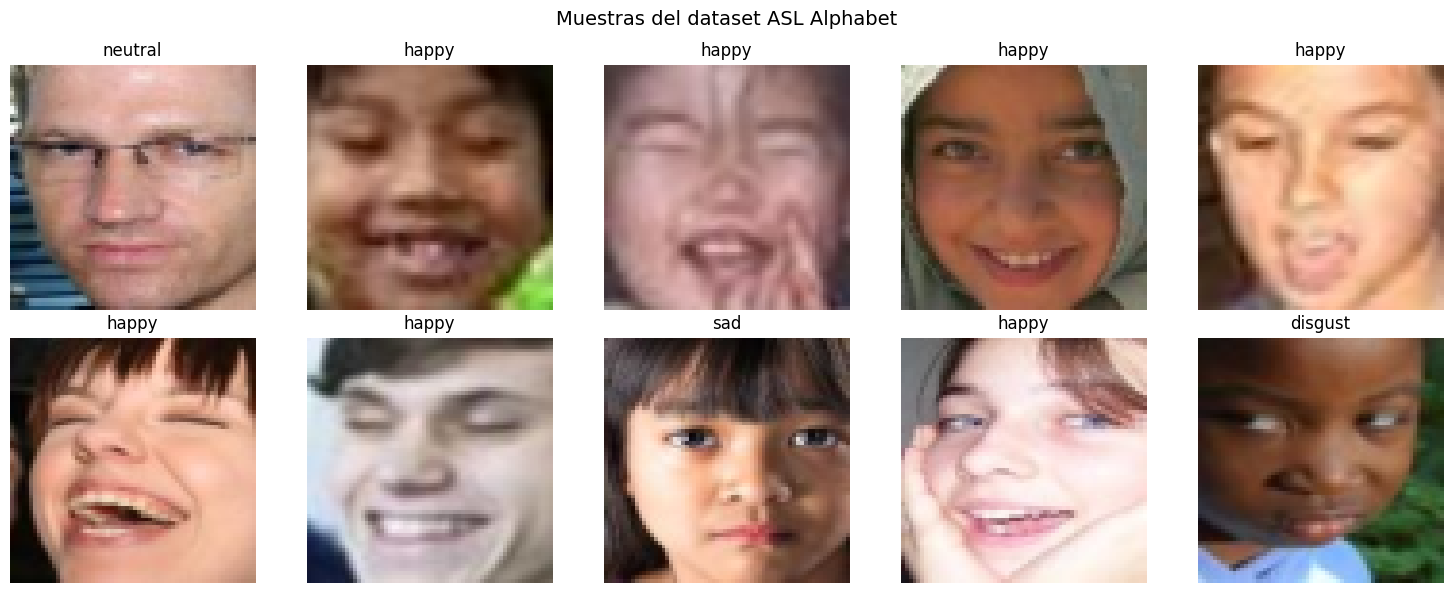

In [11]:
# --- Visualización de muestras del dataset ---
# Mostrar algunas imágenes de ejemplo para verificar que la carga es correcta

# Desnormalizar para visualizar (invertir la normalización de ImageNet)
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Invierte la normalización para poder visualizar la imagen."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)  # t = t * std + mean
    return torch.clamp(tensor, 0, 1)  # Asegurar rango [0, 1]

# Obtener nombres de las clases (invertir class_to_idx)
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(imgs[i])              # Desnormalizar
    img = img.permute(1, 2, 0).numpy()      # De [C, H, W] a [H, W, C] para matplotlib
    ax.imshow(img)
    ax.set_title(idx_to_class[labels[i].item()], fontsize=12)
    ax.axis("off")
plt.suptitle("Muestras del dataset ASL Alphabet", fontsize=14)
plt.tight_layout()
plt.show()

## Fase 2 — Arquitectura CNN Baseline

Arquitectura CNN diseñada desde cero para clasificar 29 clases de señas ASL.

**Características del modelo:**
- 4 bloques convolucionales con BatchNorm + ReLU + MaxPool
- Dropout para regularización
- Clasificador fully-connected al final
- Modelo exportado en FP32 (sin optimizaciones)

> **Nota:** Este modelo se guarda intacto para luego aplicar técnicas de compresión (Fase 3): pruning, cuantización, destilación, etc.

### Modelo Baseline

In [12]:
# ============================================================
# Definición de la arquitectura CNN Baseline
# ============================================================
# Esta clase se reutilizará en la Fase 3 para aplicar pruning,
# cuantización (PTQ/QAT), destilación, etc.
# Por eso la definimos como una clase separada y limpia.

class ASLBaselineCNN(nn.Module):
    """
    CNN para clasificación de señas ASL (29 clases).
    Arquitectura: 4 bloques conv + clasificador FC.

    Cada bloque convolucional:
        Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d

    Entrada: imágenes RGB de 64x64 (3 canales)
    Salida: vector de 29 logits (uno por clase)
    """

    def __init__(self, num_classes=7):
        super(ASLBaselineCNN, self).__init__()

        # --- Bloque 1: 3 canales -> 32 filtros ---
        # Conv2d: kernel 3x3, padding 1 para mantener dimensión espacial
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # [B, 3, 64, 64] -> [B, 32, 64, 64]
            nn.BatchNorm2d(32),                             # Normaliza activaciones (estabiliza entrenamiento)
            nn.ReLU(inplace=True),                          # Activación no lineal
            nn.MaxPool2d(2, 2)                              # Reduce a la mitad: [B, 32, 32, 32]
        )

        # --- Bloque 2: 32 -> 64 filtros ---
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # [B, 32, 32, 32] -> [B, 64, 32, 32]
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                              # -> [B, 64, 16, 16]
        )

        # --- Bloque 3: 64 -> 128 filtros ---
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # [B, 64, 16, 16] -> [B, 128, 16, 16]
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                              # -> [B, 128, 8, 8]
        )

        # --- Bloque 4: 128 -> 256 filtros ---
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # [B, 128, 8, 8] -> [B, 256, 8, 8]
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                              # -> [B, 256, 4, 4]
        )

        # --- Clasificador Fully Connected ---
        # Aplanamos: 256 * 4 * 4 = 4096 features
        self.classifier = nn.Sequential(
            nn.Flatten(),                                   # [B, 256, 4, 4] -> [B, 4096]
            nn.Dropout(0.3),                                # Dropout 30% para evitar overfitting
            nn.Linear(256 * 4 * 4, 512),                   # Capa oculta
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),                                # Dropout 30%
            nn.Linear(512, num_classes)                     # Capa de salida: 29 logits
        )

    def forward(self, x):
        """Forward pass: imagen -> logits de cada clase."""
        x = self.conv1(x)    # Bloque convolucional 1
        x = self.conv2(x)    # Bloque convolucional 2
        x = self.conv3(x)    # Bloque convolucional 3
        x = self.conv4(x)    # Bloque convolucional 4
        x = self.classifier(x)  # Clasificador FC
        return x


# --- Instanciar modelo y mover a GPU ---
model = ASLBaselineCNN(num_classes=NUM_CLASSES).to(device)

# --- Métricas del modelo baseline ---
# Contar parámetros totales y entrenables
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

# Calcular MACs (Multiply-Accumulate Operations) - complejidad teórica
# Creamos un input dummy del tamaño correcto
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
macs, params = profile(model, inputs=(dummy_input,), verbose=False)
macs_str, params_str = clever_format([macs, params], "%.2f")
print(f"MACs (complejidad teórica): {macs_str}")
print(f"Parámetros (thop): {params_str}")

# Tamaño del modelo en memoria (FP32)
param_size_mb = total_params * 4 / (1024 ** 2)  # 4 bytes por parámetro FP32
print(f"Tamaño estimado del modelo (FP32): {param_size_mb:.2f} MB")

# Mostrar arquitectura
print(f"\n{model}")

Parámetros totales: 2,490,631
Parámetros entrenables: 2,490,631
MACs (complejidad teórica): 63.25M
Parámetros (thop): 2.49M
Tamaño estimado del modelo (FP32): 9.50 MB

ASLBaselineCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=

In [13]:
# ============================================================
# Entrenamiento del modelo baseline
# ============================================================

# Función de pérdida: CrossEntropyLoss (estándar para clasificación multiclase)
# Internamente aplica Softmax + NLLLoss
criterion = nn.CrossEntropyLoss()

# Optimizador: Adam (adaptativo, buen balance velocidad/precisión)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Entrena el modelo por una época completa.
    Retorna: (loss promedio, accuracy) de la época.
    """
    model.train()  # Modo entrenamiento (activa Dropout, BatchNorm en modo train)
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        # Mover datos a GPU
        images, labels = images.to(device), labels.to(device)

        # Forward pass: obtener predicciones
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass: calcular gradientes y actualizar pesos
        optimizer.zero_grad()   # Limpiar gradientes anteriores
        loss.backward()         # Calcular gradientes
        optimizer.step()        # Actualizar pesos

        # Acumular métricas
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)  # Clase con mayor probabilidad
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Imprimir progreso cada 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """
    Evalúa el modelo en el conjunto de validación.
    Retorna: (loss promedio, accuracy).
    """
    model.eval()  # Modo evaluación (desactiva Dropout, BatchNorm en modo eval)
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # No calcular gradientes (ahorra memoria y tiempo)
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


# --- Bucle de entrenamiento ---
print("=" * 60)
print("INICIANDO ENTRENAMIENTO DEL BASELINE")
print("=" * 60)

# Guardar historial para graficar después
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0       # Mejor accuracy de validación
best_model_state = None   # Guardar los pesos del mejor modelo

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # Entrenar una época
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Validar
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Guardar historial
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Guardar mejor modelo (early stopping manual basado en accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  ★ Nuevo mejor modelo guardado (val_acc: {val_acc:.2f}%)")

    epoch_time = time.time() - epoch_start
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] ({epoch_time:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print("-" * 60)

total_time = time.time() - start_time
print(f"\nEntrenamiento completo en {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Mejor accuracy de validación: {best_val_acc:.2f}%")

# Restaurar los pesos del mejor modelo
model.load_state_dict(best_model_state)
print("Pesos del mejor modelo restaurados.")

INICIANDO ENTRENAMIENTO DEL BASELINE
  Batch 100/192 - Loss: 1.6457
  ★ Nuevo mejor modelo guardado (val_acc: 55.19%)
Época [1/25] (21.3s) | Train Loss: 1.6065 | Train Acc: 41.32% | Val Loss: 1.2496 | Val Acc: 55.19%
------------------------------------------------------------
  Batch 100/192 - Loss: 1.1822
  ★ Nuevo mejor modelo guardado (val_acc: 64.71%)
Época [2/25] (10.9s) | Train Loss: 1.1869 | Train Acc: 56.90% | Val Loss: 0.9980 | Val Acc: 64.71%
------------------------------------------------------------
  Batch 100/192 - Loss: 1.0536
  ★ Nuevo mejor modelo guardado (val_acc: 67.97%)
Época [3/25] (12.2s) | Train Loss: 1.0045 | Train Acc: 63.63% | Val Loss: 0.9008 | Val Acc: 67.97%
------------------------------------------------------------
  Batch 100/192 - Loss: 0.9234
  ★ Nuevo mejor modelo guardado (val_acc: 73.45%)
Época [4/25] (9.8s) | Train Loss: 0.8724 | Train Acc: 68.98% | Val Loss: 0.7704 | Val Acc: 73.45%
------------------------------------------------------------


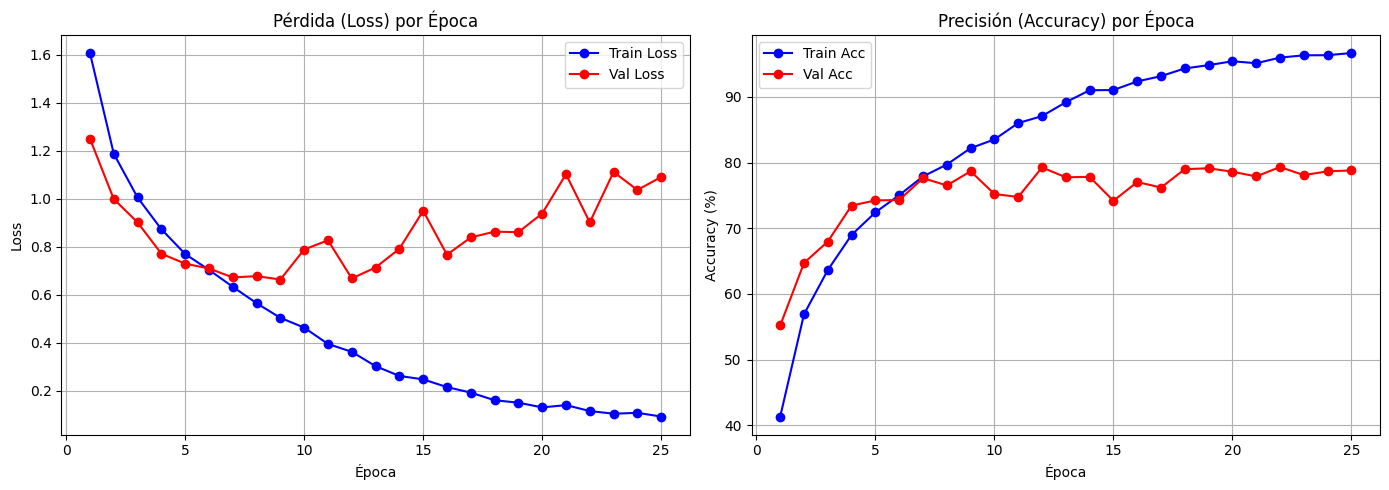

In [14]:
# --- Gráficos de entrenamiento ---
# Visualizar la evolución de loss y accuracy durante el entrenamiento

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss
ax1.plot(range(1, NUM_EPOCHS+1), history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(range(1, NUM_EPOCHS+1), history['val_loss'], 'r-o', label='Val Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Pérdida (Loss) por Época')
ax1.legend()
ax1.grid(True)

# Gráfico de Accuracy
ax2.plot(range(1, NUM_EPOCHS+1), history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(range(1, NUM_EPOCHS+1), history['val_acc'], 'r-o', label='Val Acc')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Precisión (Accuracy) por Época')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Métricas Baseline (Fase 2)

Registro riguroso de las métricas del modelo original (FP32) que servirán como referencia para comparar contra los modelos optimizados en la Fase 3.

In [16]:
# ============================================================
# Guardar modelo baseline y artefactos para Fase 3
# ============================================================
# Guardamos todo lo necesario para poder aplicar técnicas de
# optimización (pruning, cuantización, destilación) sin tener
# que volver a entrenar desde cero.

# 1. Guardar state_dict (pesos del modelo - formato estándar para PyTorch)
torch.save(model.state_dict(), "asl_baseline_model.pth")
print("✓ Modelo baseline guardado: asl_baseline_model.pth")


✓ Modelo baseline guardado: asl_baseline_model.pth


In [17]:
model.load_state_dict(torch.load("asl_baseline_model.pth", map_location=device))

# -------- FP32 --------
fp32_cpu = evaluate_model(model, "FP32_CPU", torch.device("cpu"))

if torch.cuda.is_available():
    fp32_gpu = evaluate_model(model, "FP32_GPU", torch.device("cuda"))
else:
    fp32_gpu = None


MÉTRICAS - FP32_CPU (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             79.32%
Loss (validación)                                 0.9008
Accuracy (test)                                   79.09%
Loss (test)                                       0.8517
Tamaño en disco                                   9.52 MB
Latencia (cpu)                                    4.98 ms
FPS (cpu)                                          201.0
Latencia CPU (ms)                                 4.98 ms
FPS CPU                                            201.0

MÉTRICAS - FP32_GPU (cuda)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             79.32%
Loss (validación)                                 0.9008
Accuracy (test)                                   79.09%
Loss (test)           

## Fase 3: Optimización de modelo

### Compresión

#### Cuantización dinámica

In [18]:
import torch
import torch.quantization as tq

In [19]:


# ----------------------------------
# 1. Preparación
# ----------------------------------
model.eval()
model.cpu()

# ----------------------------------
# 2. Quantization dinámica
# (solo afecta capas Linear)
# ----------------------------------
model_int8 = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.Linear},   # solo capas fully connected
    dtype=torch.qint8
)

# ----------------------------------
# 3. Evaluación
# ----------------------------------
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to("cpu")
        labels = labels.to("cpu")

        outputs = model_int8(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy INT8 (dynamic): {100 * correct / total:.2f}%")

/tmp/ipykernel_1572/208226545.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.quantization.quantize_dynamic(


Accuracy INT8 (dynamic): 79.15%


In [20]:
# -------- int8 --------
int8_dynamic = evaluate_model(model_int8, "INT8_CPU", torch.device("cpu"))


MÉTRICAS - INT8_CPU (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             79.39%
Loss (validación)                                 0.9004
Accuracy (test)                                   79.15%
Loss (test)                                       0.8512
Tamaño en disco                                   3.51 MB
Latencia (cpu)                                    4.68 ms
FPS (cpu)                                          213.7
Latencia CPU (ms)                                 4.68 ms
FPS CPU                                            213.7


In [21]:
models = {
    "FP32 GPU": fp32_gpu,
    "FP32 CPU": fp32_cpu,
    "INT8 Dynamic": int8_dynamic
}

print_comparison_table(models)


COMPARACIÓN FINAL
Métrica                         FP32 GPU       FP32 CPU   INT8 Dynamic
----------------------------------------------------------------------
Accuracy (%)                      79.088         79.088         79.153
Tamaño (MB)                        9.517          9.516          3.507
Latencia device (ms)               0.988          4.975          4.679
FPS device                      1011.959        201.003        213.722
Latencia CPU (ms)                  7.268          4.975          4.679
FPS CPU                          137.592        201.003        213.722


#### Cuantización estática



In [22]:
state_dict = torch.load("asl_baseline_model.pth")

clean_state_dict = {
    k: v for k, v in state_dict.items()
    if "total_ops" not in k and "total_params" not in k
}

model_q = ASLBaselineCNN(num_classes=NUM_CLASSES)
model_q.load_state_dict(clean_state_dict)

<All keys matched successfully>

In [23]:
model_q.eval()
model_q.cpu()

torch.backends.quantized.engine = 'fbgemm'

In [24]:
import torch.nn as nn
import torch.quantization as tq

class QuantWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.quant = tq.QuantStub()
        self.model = model
        self.dequant = tq.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.model(x)
        x = self.dequant(x)
        return x

In [25]:
model_fp32 = ASLBaselineCNN(num_classes=NUM_CLASSES)
model_fp32.load_state_dict(clean_state_dict)
model_fp32.eval()
model_fp32.cpu()

model_q = QuantWrapper(model_fp32)

In [26]:
torch.backends.quantized.engine = 'fbgemm'

fusion_list = [
    ['model.conv1.0', 'model.conv1.1', 'model.conv1.2'],
    ['model.conv2.0', 'model.conv2.1', 'model.conv2.2'],
    ['model.conv3.0', 'model.conv3.1', 'model.conv3.2'],
    ['model.conv4.0', 'model.conv4.1', 'model.conv4.2'],
]

model_fused = tq.fuse_modules(model_q, fusion_list)

model_fused.qconfig = tq.get_default_qconfig('fbgemm')

tq.prepare(model_fused, inplace=True)

# calibración
with torch.no_grad():
    for images, _ in val_loader:
        model_fused(images.to("cpu"))

tq.convert(model_fused, inplace=True)

/tmp/ipykernel_1572/26188940.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  tq.prepare(model_fused, inplace=True)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  sup

QuantWrapper(
  (quant): Quantize(scale=tensor([0.0374]), zero_point=tensor([57]), dtype=torch.quint8)
  (model): ASLBaselineCNN(
    (conv1): Sequential(
      (0): QuantizedConvReLU2d(3, 32, kernel_size=(3, 3), stride=(1, 1), scale=0.07580763101577759, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv2): Sequential(
      (0): QuantizedConvReLU2d(32, 64, kernel_size=(3, 3), stride=(1, 1), scale=0.052663810551166534, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv3): Sequential(
      (0): QuantizedConvReLU2d(64, 128, kernel_size=(3, 3), stride=(1, 1), scale=0.04219542443752289, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

In [27]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to("cpu")
        labels = labels.to("cpu")

        outputs = model_fused(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc_int8_static = 100 * correct / total
print(f"Accuracy INT8 (static): {acc_int8_static:.2f}%")

Accuracy INT8 (static): 78.63%


In [28]:
torch.save(model_fused.state_dict(), "int8_static_model.pth")
print("✓ Modelo baseline guardado: int8_static_model.pth")

✓ Modelo baseline guardado: int8_static_model.pth


In [29]:
# -------- int8 --------
int8_static = evaluate_model(model_fused, "INT8_CPU", torch.device("cpu"))


MÉTRICAS - INT8_CPU (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             79.26%
Loss (validación)                                 0.9028
Accuracy (test)                                   78.63%
Loss (test)                                       0.8564
Tamaño en disco                                   2.40 MB
Latencia (cpu)                                    2.83 ms
FPS (cpu)                                          352.8
Latencia CPU (ms)                                 2.83 ms
FPS CPU                                            352.8


In [30]:
models = {
    "FP32 GPU": fp32_gpu,
    "FP32 CPU": fp32_cpu,
    "INT8 Dynamic": int8_dynamic,
    "INT8 Static": int8_static,
}
print_comparison_table(models)


COMPARACIÓN FINAL
Métrica                         FP32 GPU       FP32 CPU   INT8 Dynamic    INT8 Static
-------------------------------------------------------------------------------------
Accuracy (%)                      79.088         79.088         79.153         78.632
Tamaño (MB)                        9.517          9.516          3.507          2.405
Latencia device (ms)               0.988          4.975          4.679          2.835
FPS device                      1011.959        201.003        213.722        352.758
Latencia CPU (ms)                  7.268          4.975          4.679          2.835
FPS CPU                          137.592        201.003        213.722        352.758


#### QAT

### Pruning

In [31]:
# Hacemos pruning estructurado para que sea agnóstico del HW. Si bien en este escenario estamos ejecutando en CPU de PC la idea es una mejora de modelo para que pueda ejecutarse por ejemplo
# en raspberry PI o dispositivos edge.

In [32]:
import torch
import torch.nn as nn

# --------------------------------------------------
# Importancia (L1 por filtro)
# --------------------------------------------------
def get_filter_importance(conv):
    return conv.weight.data.abs().sum(dim=(1, 2, 3))


# --------------------------------------------------
# PRUNING ESTRUCTURADO REAL
# --------------------------------------------------
def build_pruned_asl_cnn(base_model, prune_ratio=0.3):

    # -------- Conv layers --------
    conv1 = base_model.conv1[0]
    conv2 = base_model.conv2[0]
    conv3 = base_model.conv3[0]
    conv4 = base_model.conv4[0]

    bn1 = base_model.conv1[1]
    bn2 = base_model.conv2[1]
    bn3 = base_model.conv3[1]
    bn4 = base_model.conv4[1]

    # -------- Selección de filtros --------
    def get_keep(conv):
        imp = get_filter_importance(conv)
        n_keep = max(1, int(conv.out_channels * (1 - prune_ratio)))
        keep = imp.topk(n_keep).indices.sort().values
        return keep, n_keep

    keep1, k1 = get_keep(conv1)
    keep2, k2 = get_keep(conv2)
    keep3, k3 = get_keep(conv3)
    keep4, k4 = get_keep(conv4)

    # -------- Crear nuevo modelo --------
    pruned = ASLBaselineCNN(num_classes=7)

    # Reconfigurar capas
    pruned.conv1[0] = nn.Conv2d(3, k1, 3, padding=1)
    pruned.conv1[1] = nn.BatchNorm2d(k1)

    pruned.conv2[0] = nn.Conv2d(k1, k2, 3, padding=1)
    pruned.conv2[1] = nn.BatchNorm2d(k2)

    pruned.conv3[0] = nn.Conv2d(k2, k3, 3, padding=1)
    pruned.conv3[1] = nn.BatchNorm2d(k3)

    pruned.conv4[0] = nn.Conv2d(k3, k4, 3, padding=1)
    pruned.conv4[1] = nn.BatchNorm2d(k4)

    # -------- Ajustar FC --------
    # Linear(4096 -> 512) está en index 2
    pruned.classifier[2] = nn.Linear(k4 * 4 * 4, 512)

    # -------- Copia de pesos --------
    with torch.no_grad():

        # ---- Conv1 ----
        pruned.conv1[0].weight.copy_(conv1.weight.data[keep1])
        pruned.conv1[0].bias.copy_(conv1.bias.data[keep1])

        pruned.conv1[1].weight.copy_(bn1.weight.data[keep1])
        pruned.conv1[1].bias.copy_(bn1.bias.data[keep1])
        pruned.conv1[1].running_mean.copy_(bn1.running_mean.data[keep1])
        pruned.conv1[1].running_var.copy_(bn1.running_var.data[keep1])

        # ---- Conv2 ----
        pruned.conv2[0].weight.copy_(conv2.weight.data[keep2][:, keep1])
        pruned.conv2[0].bias.copy_(conv2.bias.data[keep2])

        pruned.conv2[1].weight.copy_(bn2.weight.data[keep2])
        pruned.conv2[1].bias.copy_(bn2.bias.data[keep2])
        pruned.conv2[1].running_mean.copy_(bn2.running_mean.data[keep2])
        pruned.conv2[1].running_var.copy_(bn2.running_var.data[keep2])

        # ---- Conv3 ----
        pruned.conv3[0].weight.copy_(conv3.weight.data[keep3][:, keep2])
        pruned.conv3[0].bias.copy_(conv3.bias.data[keep3])

        pruned.conv3[1].weight.copy_(bn3.weight.data[keep3])
        pruned.conv3[1].bias.copy_(bn3.bias.data[keep3])
        pruned.conv3[1].running_mean.copy_(bn3.running_mean.data[keep3])
        pruned.conv3[1].running_var.copy_(bn3.running_var.data[keep3])

        # ---- Conv4 ----
        pruned.conv4[0].weight.copy_(conv4.weight.data[keep4][:, keep3])
        pruned.conv4[0].bias.copy_(conv4.bias.data[keep4])

        pruned.conv4[1].weight.copy_(bn4.weight.data[keep4])
        pruned.conv4[1].bias.copy_(bn4.bias.data[keep4])
        pruned.conv4[1].running_mean.copy_(bn4.running_mean.data[keep4])
        pruned.conv4[1].running_var.copy_(bn4.running_var.data[keep4])

        # -------- FC --------
        fc1_base = base_model.classifier[2]
        fc2_base = base_model.classifier[5]

        fc1_pruned = pruned.classifier[2]
        fc2_pruned = pruned.classifier[5]

        # Cada canal → 4x4 = 16 features
        keep4_flat = torch.cat([keep4 * 16 + i for i in range(16)]).sort().values

        fc1_pruned.weight.copy_(fc1_base.weight.data[:, keep4_flat])
        fc1_pruned.bias.copy_(fc1_base.bias.data)

        fc2_pruned.weight.copy_(fc2_base.weight.data)
        fc2_pruned.bias.copy_(fc2_base.bias.data)

    return pruned

In [33]:
pruned_model = build_pruned_asl_cnn(model, prune_ratio=0.4).to(device)

In [34]:
# Fine-tuning
# ============================================================
# FINE-TUNING MODELO PODADO
# ============================================================

pruned_model = build_pruned_asl_cnn(model, prune_ratio=0.4).to(device)

criterion = nn.CrossEntropyLoss()

# se debe cambiar optimizer
optimizer = optim.Adam(pruned_model.parameters(), lr=1e-4)

print("=" * 60)
print("FINE-TUNING DEL MODELO PODADO")
print("=" * 60)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0
best_model_state = None

NUM_EPOCHS = 5  # menos épocas

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # usamos pruned_model
    train_loss, train_acc = train_one_epoch(
        pruned_model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate(
        pruned_model, val_loader, criterion, device
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(pruned_model.state_dict())
        print(f"  ★ Nuevo mejor modelo (val_acc: {val_acc:.2f}%)")

    epoch_time = time.time() - epoch_start
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] ({epoch_time:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print("-" * 60)

total_time = time.time() - start_time

print(f"\nFine-tuning completo en {total_time:.1f}s")
print(f"Mejor accuracy (pruned): {best_val_acc:.2f}%")

# restaurar mejor modelo PODADO
pruned_model.load_state_dict(best_model_state)

FINE-TUNING DEL MODELO PODADO
  Batch 100/192 - Loss: 0.5574
  ★ Nuevo mejor modelo (val_acc: 73.84%)
Época [1/5] (11.3s) | Train Loss: 0.7099 | Train Acc: 76.26% | Val Loss: 0.7987 | Val Acc: 73.84%
------------------------------------------------------------
  Batch 100/192 - Loss: 0.4681
  ★ Nuevo mejor modelo (val_acc: 75.93%)
Época [2/5] (9.6s) | Train Loss: 0.5201 | Train Acc: 81.75% | Val Loss: 0.7647 | Val Acc: 75.93%
------------------------------------------------------------
  Batch 100/192 - Loss: 0.5286
  ★ Nuevo mejor modelo (val_acc: 76.91%)
Época [3/5] (10.9s) | Train Loss: 0.4299 | Train Acc: 84.71% | Val Loss: 0.7503 | Val Acc: 76.91%
------------------------------------------------------------
  Batch 100/192 - Loss: 0.4786
  ★ Nuevo mejor modelo (val_acc: 78.34%)
Época [4/5] (11.9s) | Train Loss: 0.3764 | Train Acc: 86.68% | Val Loss: 0.7337 | Val Acc: 78.34%
------------------------------------------------------------
  Batch 100/192 - Loss: 0.4306
Época [5/5] (11.

<All keys matched successfully>

In [35]:
# Guardar state_dict (pesos del modelo - formato estándar para PyTorch)
torch.save(pruned_model.state_dict(), "pruned_model.pth")
print("✓ Modelo pruned guardado: pruned_model.pth")

✓ Modelo pruned guardado: pruned_model.pth


In [36]:
# -------- pruned --------
pruned_model.load_state_dict(torch.load("pruned_model.pth", torch.device("cpu")))
fp32_pruned = evaluate_model(pruned_model, "PRUNED CPU", torch.device("cpu"))


MÉTRICAS - PRUNED CPU (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             78.34%
Loss (validación)                                 0.7337
Accuracy (test)                                   75.77%
Loss (test)                                       0.7457
Tamaño en disco                                   5.34 MB
Latencia (cpu)                                    2.92 ms
FPS (cpu)                                          342.8
Latencia CPU (ms)                                 2.92 ms
FPS CPU                                            342.8


In [37]:
models = {
    "FP32 GPU": fp32_gpu,
    "FP32 CPU": fp32_cpu,
    "INT8 Dynamic": int8_dynamic,
    "INT8 Static": int8_static,
    "FP32 Pruned": fp32_pruned
}
print_comparison_table(models)


COMPARACIÓN FINAL
Métrica                         FP32 GPU       FP32 CPU   INT8 Dynamic    INT8 Static    FP32 Pruned
----------------------------------------------------------------------------------------------------
Accuracy (%)                      79.088         79.088         79.153         78.632         75.765
Tamaño (MB)                        9.517          9.516          3.507          2.405          5.337
Latencia device (ms)               0.988          4.975          4.679          2.835          2.917
FPS device                      1011.959        201.003        213.722        352.758        342.768
Latencia CPU (ms)                  7.268          4.975          4.679          2.835          2.917
FPS CPU                          137.592        201.003        213.722        352.758        342.768


### Pruning + Cuantización

#### Cuantizacion din

In [38]:
# Cuantización dinamica a int8 a modelo pruned.

In [39]:
# ----------------------------------
# 1. Preparación
# ----------------------------------
pruned_model.eval()
pruned_model.cpu()

# ----------------------------------
# 2. Quantization dinámica
# (solo afecta capas Linear)
# ----------------------------------
pruned_model_int8 = torch.quantization.quantize_dynamic(
    pruned_model,
    {torch.nn.Linear},   #solo capas fully connected
    dtype=torch.qint8
)

# ----------------------------------
# 3. Evaluación
# ----------------------------------
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to("cpu")
        labels = labels.to("cpu")

        outputs = pruned_model_int8(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy INT8 (dynamic): {100 * correct / total:.2f}%")

/tmp/ipykernel_1572/784235680.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  pruned_model_int8 = torch.quantization.quantize_dynamic(


Accuracy INT8 (dynamic): 75.64%


In [40]:
# -------- int8 --------
pruned_int8_dynamic = evaluate_model(pruned_model_int8, "INT8_DYN_CPU", torch.device("cpu"))


MÉTRICAS - INT8_DYN_CPU (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             78.28%
Loss (validación)                                 0.7337
Accuracy (test)                                   75.64%
Loss (test)                                       0.7466
Tamaño en disco                                   1.74 MB
Latencia (cpu)                                    3.11 ms
FPS (cpu)                                          321.3
Latencia CPU (ms)                                 3.11 ms
FPS CPU                                            321.3


In [41]:
models = {
    "FP32 GPU": fp32_gpu,
    "FP32 CPU": fp32_cpu,
    "INT8 Dynamic": int8_dynamic,
    "INT8 Static": int8_static,
    "FP32 Pruned": fp32_pruned,
    "INT8 Dyn. Pruned": pruned_int8_dynamic
}
print_comparison_table(models)


COMPARACIÓN FINAL
Métrica                         FP32 GPU       FP32 CPU   INT8 Dynamic    INT8 Static    FP32 PrunedINT8 Dyn. Pruned
-------------------------------------------------------------------------------------------------------------------
Accuracy (%)                      79.088         79.088         79.153         78.632         75.765         75.635
Tamaño (MB)                        9.517          9.516          3.507          2.405          5.337          1.743
Latencia device (ms)               0.988          4.975          4.679          2.835          2.917          3.113
FPS device                      1011.959        201.003        213.722        352.758        342.768        321.259
Latencia CPU (ms)                  7.268          4.975          4.679          2.835          2.917          3.113
FPS CPU                          137.592        201.003        213.722        352.758        342.768        321.259


#### Cuantizacion Estatica

In [42]:
state_dict = torch.load("pruned_model.pth")

clean_state_dict = {
    k: v for k, v in state_dict.items()
    if "total_ops" not in k and "total_params" not in k
}

import copy
model_q_pruned = copy.deepcopy(pruned_model)
model_q_pruned.load_state_dict(clean_state_dict)

<All keys matched successfully>

In [43]:
model_q_pruned.eval()
model_q_pruned.cpu()

torch.backends.quantized.engine = 'fbgemm'

In [44]:
import torch.nn as nn
import torch.quantization as tq

class QuantWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.quant = tq.QuantStub()
        self.model = model
        self.dequant = tq.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.model(x)
        x = self.dequant(x)
        return x

In [45]:
model_pruned_fp32 = pruned_model
model_pruned_fp32.load_state_dict(clean_state_dict)
model_pruned_fp32.eval()
model_pruned_fp32.cpu()

model_q_pruned = QuantWrapper(model_pruned_fp32)

In [46]:
torch.backends.quantized.engine = 'fbgemm'

fusion_list = [
    ['model.conv1.0', 'model.conv1.1', 'model.conv1.2'],
    ['model.conv2.0', 'model.conv2.1', 'model.conv2.2'],
    ['model.conv3.0', 'model.conv3.1', 'model.conv3.2'],
    ['model.conv4.0', 'model.conv4.1', 'model.conv4.2'],
]

model_fused_pruned = tq.fuse_modules(model_q_pruned, fusion_list)

model_fused_pruned.qconfig = tq.get_default_qconfig('fbgemm')

tq.prepare(model_fused_pruned, inplace=True)

# calibración
with torch.no_grad():
    for images, _ in val_loader:
        model_fused_pruned(images.to("cpu"))

tq.convert(model_fused_pruned, inplace=True)

/tmp/ipykernel_1572/361805590.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  tq.prepare(model_fused_pruned, inplace=True)
/tmp/ipykernel_1572/361805590.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynam

QuantWrapper(
  (quant): Quantize(scale=tensor([0.0374]), zero_point=tensor([57]), dtype=torch.quint8)
  (model): ASLBaselineCNN(
    (conv1): Sequential(
      (0): QuantizedConvReLU2d(3, 19, kernel_size=(3, 3), stride=(1, 1), scale=0.07098302990198135, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv2): Sequential(
      (0): QuantizedConvReLU2d(19, 38, kernel_size=(3, 3), stride=(1, 1), scale=0.051286481320858, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv3): Sequential(
      (0): QuantizedConvReLU2d(38, 76, kernel_size=(3, 3), stride=(1, 1), scale=0.03906220942735672, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   

In [47]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to("cpu")
        labels = labels.to("cpu")

        outputs = model_fused_pruned(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc_int8_static = 100 * correct / total
print(f"Accuracy INT8 (static): {acc_int8_static:.2f}%")

Accuracy INT8 (static): 75.50%


In [48]:
torch.save(model_fused_pruned.state_dict(), "int8_static_pruned_model.pth")
print("✓ Modelo baseline guardado: int8_static_pruned_model.pth")

✓ Modelo baseline guardado: int8_static_pruned_model.pth


In [49]:
# -------- int8 --------
int8_pruned_static = evaluate_model(model_fused_pruned, "INT8 St. Pruned", torch.device("cpu"))


MÉTRICAS - INT8 St. Pruned (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             78.15%
Loss (validación)                                 0.7329
Accuracy (test)                                   75.50%
Loss (test)                                       0.7488
Tamaño en disco                                   1.36 MB
Latencia (cpu)                                    3.77 ms
FPS (cpu)                                          265.3
Latencia CPU (ms)                                 3.77 ms
FPS CPU                                            265.3


In [50]:
models = {
    "FP32 GPU": fp32_gpu,
    "FP32 CPU": fp32_cpu,
    "INT8 Dynamic": int8_dynamic,
    "INT8 Static": int8_static,
    "FP32 Pruned": fp32_pruned,
    "INT8 Dyn. Pruned": pruned_int8_dynamic,
    "INT8 St. Pruned": int8_pruned_static
}
print_comparison_table(models)


COMPARACIÓN FINAL
Métrica                         FP32 GPU       FP32 CPU   INT8 Dynamic    INT8 Static    FP32 PrunedINT8 Dyn. PrunedINT8 St. Pruned
----------------------------------------------------------------------------------------------------------------------------------
Accuracy (%)                      79.088         79.088         79.153         78.632         75.765         75.635         75.505
Tamaño (MB)                        9.517          9.516          3.507          2.405          5.337          1.743          1.358
Latencia device (ms)               0.988          4.975          4.679          2.835          2.917          3.113          3.769
FPS device                      1011.959        201.003        213.722        352.758        342.768        321.259        265.294
Latencia CPU (ms)                  7.268          4.975          4.679          2.835          2.917          3.113          3.769
FPS CPU                          137.592        201.003        

### Factorizacion

In [51]:
# En este caso no trabajamos sobre la pruned si no sobre la baseline para comparar impacto individual.

In [52]:
class FactorizedConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=(3,1), padding=(1,0)),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=(1,3), padding=(0,1))
        )

    def forward(self, x):
        return self.block(x)

In [53]:
class ASLFactorizedCNN(nn.Module):

    def __init__(self, num_classes=29):
        super().__init__()

        # --- Bloque 1 ---
        self.conv1 = nn.Sequential(
            FactorizedConv(3, 32),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # --- Bloque 2 ---
        self.conv2 = nn.Sequential(
            FactorizedConv(32, 64),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # --- Bloque 3 ---
        self.conv3 = nn.Sequential(
            FactorizedConv(64, 128),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # --- Bloque 4 ---
        self.conv4 = nn.Sequential(
            FactorizedConv(128, 256),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # --- Clasificador ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.classifier(x)
        return x

In [54]:
# Entrenamos en gpu ejecutams en cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [55]:
model_fact = ASLFactorizedCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fact.parameters(), lr=LEARNING_RATE)

In [56]:
# ============================================================
# Entrenamiento del modelo factorizado
# ============================================================

print("=" * 60)
print("INICIANDO ENTRENAMIENTO DEL MODELO FACTORIZADO")
print("=" * 60)

# Guardar historial para graficar después
history_fact = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0       # Mejor accuracy de validación
best_model_state = None   # Guardar los pesos del mejor modelo
NUM_EPOCHS=10

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # Entrenar una época
    train_loss, train_acc = train_one_epoch(model_fact, train_loader, criterion, optimizer, device)

    # Validar
    val_loss, val_acc = validate(model_fact, val_loader, criterion, device)

    # Guardar historial
    history_fact['train_loss'].append(train_loss)
    history_fact['train_acc'].append(train_acc)
    history_fact['val_loss'].append(val_loss)
    history_fact['val_acc'].append(val_acc)

    # Guardar mejor modelo (early stopping manual basado en accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model_fact.state_dict())
        print(f"  ★ Nuevo mejor modelo guardado (val_acc: {val_acc:.2f}%)")

    epoch_time = time.time() - epoch_start
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] ({epoch_time:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print("-" * 60)

total_time = time.time() - start_time
print(f"\nEntrenamiento completo en {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Mejor accuracy de validación: {best_val_acc:.2f}%")

# Restaurar los pesos del mejor modelo
model_fact.load_state_dict(best_model_state)
print("Pesos del mejor modelo restaurados.")

INICIANDO ENTRENAMIENTO DEL MODELO FACTORIZADO
  Batch 100/192 - Loss: 1.6454
  ★ Nuevo mejor modelo guardado (val_acc: 46.90%)
Época [1/10] (11.1s) | Train Loss: 1.6506 | Train Acc: 40.52% | Val Loss: 1.4358 | Val Acc: 46.90%
------------------------------------------------------------
  Batch 100/192 - Loss: 1.4077
  ★ Nuevo mejor modelo guardado (val_acc: 57.66%)
Época [2/10] (11.9s) | Train Loss: 1.2336 | Train Acc: 54.45% | Val Loss: 1.2316 | Val Acc: 57.66%
------------------------------------------------------------
  Batch 100/192 - Loss: 0.9351
  ★ Nuevo mejor modelo guardado (val_acc: 68.56%)
Época [3/10] (11.5s) | Train Loss: 0.9608 | Train Acc: 65.07% | Val Loss: 0.9039 | Val Acc: 68.56%
------------------------------------------------------------
  Batch 100/192 - Loss: 0.6633
  ★ Nuevo mejor modelo guardado (val_acc: 71.04%)
Época [4/10] (9.9s) | Train Loss: 0.8180 | Train Acc: 70.52% | Val Loss: 0.8195 | Val Acc: 71.04%
---------------------------------------------------

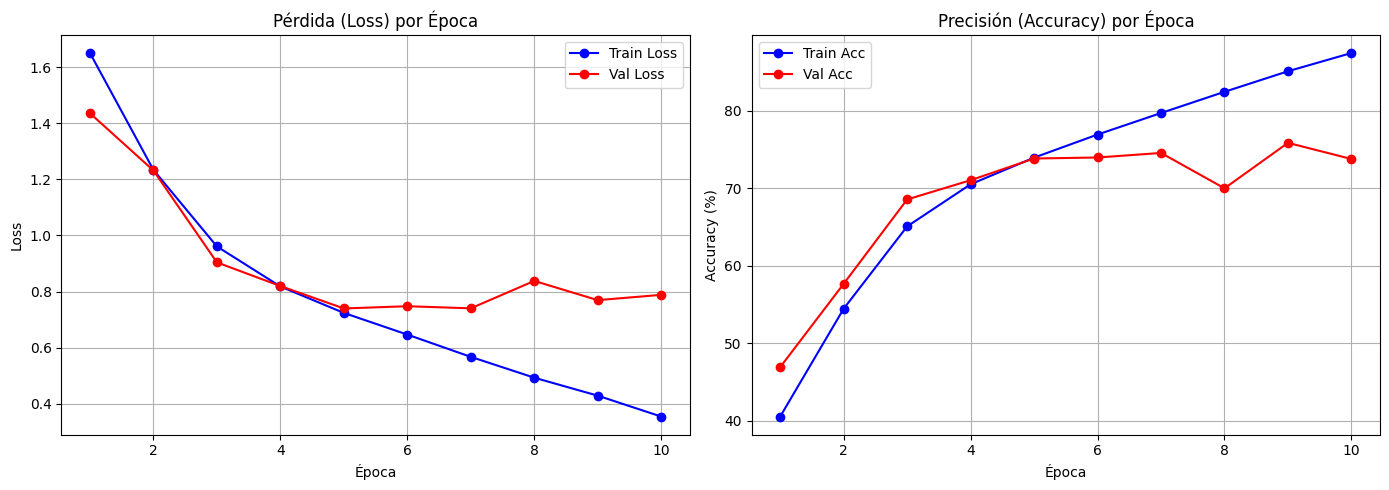

In [57]:
# --- Gráficos de entrenamiento ---
# Visualizar la evolución de loss y accuracy durante el entrenamiento

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss
ax1.plot(range(1, NUM_EPOCHS+1), history_fact['train_loss'], 'b-o', label='Train Loss')
ax1.plot(range(1, NUM_EPOCHS+1), history_fact['val_loss'], 'r-o', label='Val Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Pérdida (Loss) por Época')
ax1.legend()
ax1.grid(True)

# Gráfico de Accuracy
ax2.plot(range(1, NUM_EPOCHS+1), history_fact['train_acc'], 'b-o', label='Train Acc')
ax2.plot(range(1, NUM_EPOCHS+1), history_fact['val_acc'], 'r-o', label='Val Acc')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Precisión (Accuracy) por Época')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [58]:
# guardamos modelo factorizado
torch.save(model_fact.state_dict(), "fact_model.pth")
print("✓ Modelo pruned guardado: pruned_model.pth")

✓ Modelo pruned guardado: pruned_model.pth


In [59]:
model_fact.load_state_dict(torch.load("fact_model.pth"), torch.device("cpu"))

# -------- FP32 --------
fact_fp32_cpu = evaluate_model(model_fact, "FP32_CPU", torch.device("cpu"))

if torch.cuda.is_available():
    fact_fp32_gpu = evaluate_model(model_fact, "FP32_GPU", torch.device("cuda"))
else:
    fact_fp32_gpu = None


MÉTRICAS - FP32_CPU (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             75.86%
Loss (validación)                                 0.7693
Accuracy (test)                                   75.57%
Loss (test)                                       0.7410
Tamaño en disco                                   9.53 MB
Latencia (cpu)                                    6.27 ms
FPS (cpu)                                          159.4
Latencia CPU (ms)                                 6.27 ms
FPS CPU                                            159.4

MÉTRICAS - FP32_GPU (cuda)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             75.86%
Loss (validación)                                 0.7693
Accuracy (test)                                   75.57%
Loss (test)           

In [60]:
models = {
    "FP32 GPU": fp32_gpu,
    "FP32 CPU": fp32_cpu,
    "INT8 Dynamic": int8_dynamic,
    "INT8 Static": int8_static,
    "FP32 Pruned": fp32_pruned,
    "INT8 Dyn. Pruned": pruned_int8_dynamic,
    "INT8 St. Pruned": int8_pruned_static,
    "FP32 Factorized": fact_fp32_cpu,
    "FP32 GPU Factorized": fact_fp32_gpu
}
print_comparison_table(models)


COMPARACIÓN FINAL
Métrica                         FP32 GPU       FP32 CPU   INT8 Dynamic    INT8 Static    FP32 PrunedINT8 Dyn. PrunedINT8 St. PrunedFP32 FactorizedFP32 GPU Factorized
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Accuracy (%)                      79.088         79.088         79.153         78.632         75.765         75.635         75.505         75.570         75.570
Tamaño (MB)                        9.517          9.516          3.507          2.405          5.337          1.743          1.358          9.529          9.530
Latencia device (ms)               0.988          4.975          4.679          2.835          2.917          3.113          3.769          6.272          1.490
FPS device                      1011.959        201.003        213.722        352.758        342.768        321.259        265.294        159.448        671.283
Latencia C

In [61]:
# No tiene demasiado sentido hacer este tipo de factorizaciones ejecutando en CPU.

### Knowledge Distillation

In [62]:
# ============================================================
# Knowledge Distillation: Teacher → Student
# ============================================================

import torch.nn.functional as F

# --- Configuración KD ---
T = 4.0          # Temperatura (suaviza las probabilidades del teacher)
ALPHA = 0.7      # Peso del loss suave (KD) vs duro (CE)
NUM_EPOCHS_KD = 10

# --- Teacher: tu mejor modelo entrenado (congelado) ---
teacher = model.to(device)
teacher.load_state_dict(torch.load("asl_baseline_model.pth", map_location=device))
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

# --- Student: tu red pruned ---
# (asumimos que pruned_model ya está creado y en device)
student = pruned_model.to(device)

# --- Optimizador para el student ---
optimizer_kd = optim.Adam(student.parameters(), lr=1e-3)


def train_one_epoch_kd(student, teacher, loader, optimizer, device, T, alpha):
    student.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward de ambas redes
        logits_student = student(images)
        with torch.no_grad():
            logits_teacher = teacher(images)

        # Loss suave: KL divergence entre distribuciones con temperatura
        soft_student = F.log_softmax(logits_student / T, dim=1)
        soft_teacher = F.softmax(logits_teacher / T, dim=1)
        loss_kd = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T * T)

        # Loss duro: CrossEntropy normal contra labels reales
        loss_ce = F.cross_entropy(logits_student, labels)

        # Loss combinado
        loss = alpha * loss_kd + (1 - alpha) * loss_ce

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(logits_student, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total


# --- Bucle de entrenamiento KD ---
print("=" * 60)
print("INICIANDO KNOWLEDGE DISTILLATION")
print(f"Teacher: ASLBaselineCNN | Student: Pruned | T={T} | α={ALPHA}")
print("=" * 60)

history_kd = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc_kd = 0.0
best_student_state = None

start_time = time.time()

for epoch in range(NUM_EPOCHS_KD):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch_kd(
        student, teacher, train_loader, optimizer_kd, device, T, ALPHA
    )
    val_loss, val_acc = validate(student, val_loader, criterion, device)

    history_kd['train_loss'].append(train_loss)
    history_kd['train_acc'].append(train_acc)
    history_kd['val_loss'].append(val_loss)
    history_kd['val_acc'].append(val_acc)

    if val_acc > best_val_acc_kd:
        best_val_acc_kd = val_acc
        best_student_state = copy.deepcopy(student.state_dict())
        print(f"  ★ Nuevo mejor student (val_acc: {val_acc:.2f}%)")

    epoch_time = time.time() - epoch_start
    print(f"Época [{epoch+1}/{NUM_EPOCHS_KD}] ({epoch_time:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print("-" * 60)

total_time = time.time() - start_time
print(f"\nKD completo en {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Mejor accuracy student: {best_val_acc_kd:.2f}%")

student.load_state_dict(best_student_state)
print("Pesos del mejor student restaurados.")

INICIANDO KNOWLEDGE DISTILLATION
Teacher: ASLBaselineCNN | Student: Pruned | T=4.0 | α=0.7
  ★ Nuevo mejor student (val_acc: 78.80%)
Época [1/10] (10.8s) | Train Loss: 1.9186 | Train Acc: 86.39% | Val Loss: 0.8543 | Val Acc: 78.80%
------------------------------------------------------------
Época [2/10] (12.3s) | Train Loss: 1.4890 | Train Acc: 89.75% | Val Loss: 0.9065 | Val Acc: 78.73%
------------------------------------------------------------
  ★ Nuevo mejor student (val_acc: 78.93%)
Época [3/10] (11.7s) | Train Loss: 1.3023 | Train Acc: 91.19% | Val Loss: 0.9278 | Val Acc: 78.93%
------------------------------------------------------------
  ★ Nuevo mejor student (val_acc: 79.45%)
Época [4/10] (9.7s) | Train Loss: 1.2007 | Train Acc: 91.97% | Val Loss: 0.9108 | Val Acc: 79.45%
------------------------------------------------------------
Época [5/10] (11.2s) | Train Loss: 1.1301 | Train Acc: 92.39% | Val Loss: 0.9131 | Val Acc: 79.26%
---------------------------------------------

In [63]:
# Guardar state_dict (pesos del modelo - formato estándar para PyTorch)
torch.save(student.state_dict(), "pruned_student_model.pth")
print("✓ Modelo pruned student guardado: pruned_student_model.pth")

✓ Modelo pruned student guardado: pruned_student_model.pth


In [64]:
# -------- studnt --------
student.load_state_dict(torch.load("pruned_student_model.pth"),torch.device("cpu"))
pruned_student = evaluate_model(student, "Pruned Student CPU", torch.device("cpu"))


MÉTRICAS - Pruned Student CPU (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             80.17%
Loss (validación)                                 0.8585
Accuracy (test)                                   79.48%
Loss (test)                                       0.8537
Tamaño en disco                                   5.34 MB
Latencia (cpu)                                    4.22 ms
FPS (cpu)                                          236.7
Latencia CPU (ms)                                 4.22 ms
FPS CPU                                            236.7


In [65]:
models = {
    "FP32 GPU": fp32_gpu,
    "FP32 CPU": fp32_cpu,
    "INT8 Dynamic": int8_dynamic,
    "INT8 Static": int8_static,
    "FP32 Pruned": fp32_pruned,
    "INT8 Dyn. Pruned": pruned_int8_dynamic,
    "INT8 St. Pruned": int8_pruned_static,
    "FP32 Factorized": fact_fp32_cpu,
    "FP32 GPU Factorized": fact_fp32_gpu,
    "KD Pruned Student": pruned_student
}
print_comparison_table(models)


COMPARACIÓN FINAL
Métrica                         FP32 GPU       FP32 CPU   INT8 Dynamic    INT8 Static    FP32 PrunedINT8 Dyn. PrunedINT8 St. PrunedFP32 FactorizedFP32 GPU FactorizedKD Pruned Student
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Accuracy (%)                      79.088         79.088         79.153         78.632         75.765         75.635         75.505         75.570         75.570         79.479
Tamaño (MB)                        9.517          9.516          3.507          2.405          5.337          1.743          1.358          9.529          9.530          5.337
Latencia device (ms)               0.988          4.975          4.679          2.835          2.917          3.113          3.769          6.272          1.490          4.225
FPS device                      1011.959        201.003        213.722        352.758        3

#### Cuantizacion estática pruned student

In [66]:
### cuantizacion estatica a la pruned student

In [67]:
state_dict = torch.load("pruned_student_model.pth")

clean_state_dict = {
    k: v for k, v in state_dict.items()
    if "total_ops" not in k and "total_params" not in k
}

import copy
model_q_pruned_student = copy.deepcopy(student)
model_q_pruned_student.load_state_dict(clean_state_dict)

<All keys matched successfully>

In [68]:
model_q_pruned.eval()
model_q_pruned.cpu()

torch.backends.quantized.engine = 'fbgemm'

In [69]:
import torch.nn as nn
import torch.quantization as tq

class QuantWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.quant = tq.QuantStub()
        self.model = model
        self.dequant = tq.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.model(x)
        x = self.dequant(x)
        return x

In [70]:
model_pruned_fp32_student = student
model_pruned_fp32_student.load_state_dict(clean_state_dict)
model_pruned_fp32_student.eval()
model_pruned_fp32_student.cpu()

model_q_pruned_student = QuantWrapper(model_pruned_fp32_student)

In [71]:
torch.backends.quantized.engine = 'fbgemm'

fusion_list = [
    ['model.conv1.0', 'model.conv1.1', 'model.conv1.2'],
    ['model.conv2.0', 'model.conv2.1', 'model.conv2.2'],
    ['model.conv3.0', 'model.conv3.1', 'model.conv3.2'],
    ['model.conv4.0', 'model.conv4.1', 'model.conv4.2'],
]

model_fused_pruned_student = tq.fuse_modules(model_q_pruned_student, fusion_list)

model_fused_pruned_student.qconfig = tq.get_default_qconfig('fbgemm')

tq.prepare(model_fused_pruned_student, inplace=True)

# calibración
with torch.no_grad():
    for images, _ in val_loader:
        model_fused_pruned_student(images.to("cpu"))

tq.convert(model_fused_pruned_student, inplace=True)

/tmp/ipykernel_1572/648177668.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  tq.prepare(model_fused_pruned_student, inplace=True)
/tmp/ipykernel_1572/648177668.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quanti

QuantWrapper(
  (quant): Quantize(scale=tensor([0.0374]), zero_point=tensor([57]), dtype=torch.quint8)
  (model): ASLBaselineCNN(
    (conv1): Sequential(
      (0): QuantizedConvReLU2d(3, 19, kernel_size=(3, 3), stride=(1, 1), scale=0.07332326471805573, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv2): Sequential(
      (0): QuantizedConvReLU2d(19, 38, kernel_size=(3, 3), stride=(1, 1), scale=0.050353750586509705, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv3): Sequential(
      (0): QuantizedConvReLU2d(38, 76, kernel_size=(3, 3), stride=(1, 1), scale=0.03674463927745819, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [72]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to("cpu")
        labels = labels.to("cpu")

        outputs = model_fused_pruned_student(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc_int8_static = 100 * correct / total
print(f"Accuracy INT8 (static): {acc_int8_static:.2f}%")

Accuracy INT8 (static): 79.09%


In [73]:
# -------- int8 --------
int8_pruned_static_student = evaluate_model(model_fused_pruned_student, "INT8 St. Student Pruned", torch.device("cpu"))


MÉTRICAS - INT8 St. Student Pruned (cpu)
Métrica                                            Valor
------------------------------------------------------------
Accuracy (validación)                             79.84%
Loss (validación)                                 0.8600
Accuracy (test)                                   79.09%
Loss (test)                                       0.8546
Tamaño en disco                                   1.36 MB
Latencia (cpu)                                    2.44 ms
FPS (cpu)                                          410.1
Latencia CPU (ms)                                 2.44 ms
FPS CPU                                            410.1


In [74]:
torch.save(model_fused_pruned_student.state_dict(), "int8_static_pruned_student_model.pth")
print("✓ Modelo baseline guardado: int8_static_pruned_student_model.pth")

✓ Modelo baseline guardado: int8_static_pruned_student_model.pth


In [75]:
models = {
    "FP32 GPU": fp32_gpu,
    "FP32 CPU": fp32_cpu,
    "INT8 Dynamic": int8_dynamic,
    "INT8 Static": int8_static,
    "FP32 Pruned": fp32_pruned,
    "INT8 Dyn. Pruned": pruned_int8_dynamic,
    "INT8 St. Pruned": int8_pruned_static,
    "FP32 Factorized": fact_fp32_cpu,
    "FP32 GPU Factorized": fact_fp32_gpu,
    "FP32 KD Pruned Student": pruned_student,
    "INT8 St. KD Pruned Student": int8_pruned_static_student
}
print_comparison_table(models)


COMPARACIÓN FINAL
Métrica                         FP32 GPU       FP32 CPU   INT8 Dynamic    INT8 Static    FP32 PrunedINT8 Dyn. PrunedINT8 St. PrunedFP32 FactorizedFP32 GPU FactorizedFP32 KD Pruned StudentINT8 St. KD Pruned Student
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Accuracy (%)                      79.088         79.088         79.153         78.632         75.765         75.635         75.505         75.570         75.570         79.479         79.088
Tamaño (MB)                        9.517          9.516          3.507          2.405          5.337          1.743          1.358          9.529          9.530          5.337          1.358
Latencia device (ms)               0.988          4.975          4.679          2.835          2.917          3.113          3.769          6.272          1.490          4.225          2.438
FPS

### Export a ONNX

In [76]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 17.8 MB/s eta 0:00:00


In [77]:
# ============================================================
# Exportación ONNX — Baseline, INT8 Static, INT8 St. Pruned, Ablation
# ============================================================

import torch

def export_to_onnx(model, model_name, onnx_path, quantized=False):
    model_cpu = model.cpu()
    model_cpu.eval()
    dummy_input = torch.randn(1, 3, 64, 64)

    if quantized:
        # Trazar con TorchScript y exportar con el path legacy completo
        traced = torch.jit.trace(model_cpu, dummy_input)
        torch.onnx.export(
            traced,
            dummy_input,
            onnx_path,
            opset_version=13,           # opset menor — el legacy no soporta 18 con quant ops
            input_names=["imagen"],
            output_names=["logits"],
            dynamo=False,
            operator_export_type=torch.onnx.OperatorExportTypes.ONNX_ATEN_FALLBACK,
        )
    else:
        torch.onnx.export(
            model_cpu, dummy_input, onnx_path,
            opset_version=18,
            input_names=["imagen"], output_names=["logits"],
        )

    print(f"✓ {model_name} exportado → {onnx_path}")
    model.to(device)


# --- Baseline ---
model.load_state_dict(torch.load("asl_baseline_model.pth", map_location="cpu"))
export_to_onnx(model, "Baseline", "baseline.onnx")

# --- INT8 Static ---
model_fused.load_state_dict(torch.load("int8_static_model.pth", map_location="cpu"))
export_to_onnx(model_fused, "INT8 Static", "int8_static_model.onnx", quantized=True)

# --- INT8 Static Pruned ---
model_fused_pruned.load_state_dict(torch.load("int8_static_pruned_model.pth", map_location="cpu"))
export_to_onnx(model_fused_pruned, "INT8 Static Pruned", "int8_static_pruned_model.onnx", quantized=True)

# --- Ablation ---
model_fused_pruned_student.load_state_dict(torch.load("int8_static_pruned_student_model.pth", map_location="cpu"))
export_to_onnx(model_fused_pruned_student, "Ablation", "ablation.onnx", quantized=True)

W0427 01:24:42.103000 1572 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0427 01:24:42.109000 1572 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0427 01:24:42.114000 1572 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0427 01:24:42.120000 1572 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ASLBaselineCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ASLBaselineCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/usr/local/lib/python3.12/dist-packages/torch/_utils.py:466: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✓ Baseline exportado → baseline.onnx


/tmp/ipykernel_1572/937248064.py:15: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1508: UserWarning: no signature found for builtin <built-in method __call__ of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 object at 0x7ab1332eab10>, skipping _decide_input_format
  args = _decide_input_format(model, args)
/usr/local/lib/python3.12/dist-packages/torch/jit/_trace.py:1016: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  traced_func = _

✓ INT8 Static exportado → int8_static_model.onnx
✓ INT8 Static Pruned exportado → int8_static_pruned_model.onnx
✓ Ablation exportado → ablation.onnx


In [79]:
# Export dataset test
# En Colab — usás el test_loader que ya tenés definido
import torch

all_images = []
all_labels = []
for images, labels in test_loader:
    all_images.append(images)
    all_labels.append(labels)

torch.save({
    "images": torch.cat(all_images),
    "labels": torch.cat(all_labels),
}, "/content/test_data.pt")

# Ver tamaño
!ls -lh /content/test_data.pt

from google.colab import files
files.download("/content/test_data.pt")

-rw-r--r-- 1 root root 72M Apr 27 01:32 /content/test_data.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>